In [1]:
import uncertainties as u
from uncertainties import umath
import uncertainties.unumpy as unp
from prettytable import PrettyTable

g = 9.8 #m/s^2

# Define measurements (value, absolute error)
d_mg1 = u.ufloat(43.8, 0.1) * g * 10**-3 #kg
d_mg2 = u.ufloat(42.9, 0.1) * g * 10**-3 #kg
L = u.ufloat(97.75, 0.01) * 10**-3 #m

k_1 = d_mg1/L
k_2 = d_mg2/L
print(f"K_1: {k_1}, K_2: {k_2}")

m = u.ufloat(207.3, 0.1) * 10**-3 #kg

table = PrettyTable(["Experiment name","Amplitude (clicks)", "Damp Factor (1/s)", "Angular Freq (rad/s)","Phase (rad)"])

print(f"Theoretical omega: {umath.sqrt((k_1+k_2)/m)} (rad/s)")

table.add_row(['Theoretical Omega', '', '', umath.sqrt((k_1+k_2)/m), ''])

K_1: 4.391+/-0.010, K_2: 4.301+/-0.010
Theoretical omega: 6.475+/-0.006 (rad/s)



--- Fit Results for Meas_1 ---
Amplitude (A): 83.861±0.171 clicks
Angular Freq (omega): 6.341163±0.000715 rad/s
Frequency (f): 1.009227±0.000114 Hz
Phase (phi): -2.40157±0.00416 rad
Offset: -0.323±0.122 clicks


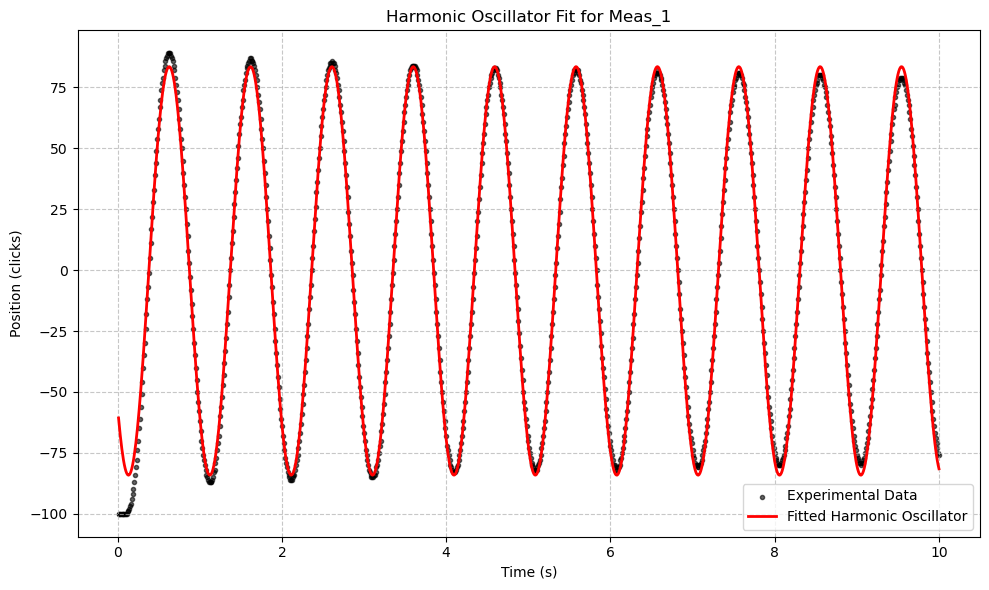


--- Fit Results for Meas_2 ---
Amplitude (A): 81.773±0.158 clicks
Angular Freq (omega): 6.342678±0.000339 rad/s
Frequency (f): 1.0094685±0.0000540 Hz
Phase (phi): -2.43179±0.00391 rad
Offset: 0.034±0.112 clicks


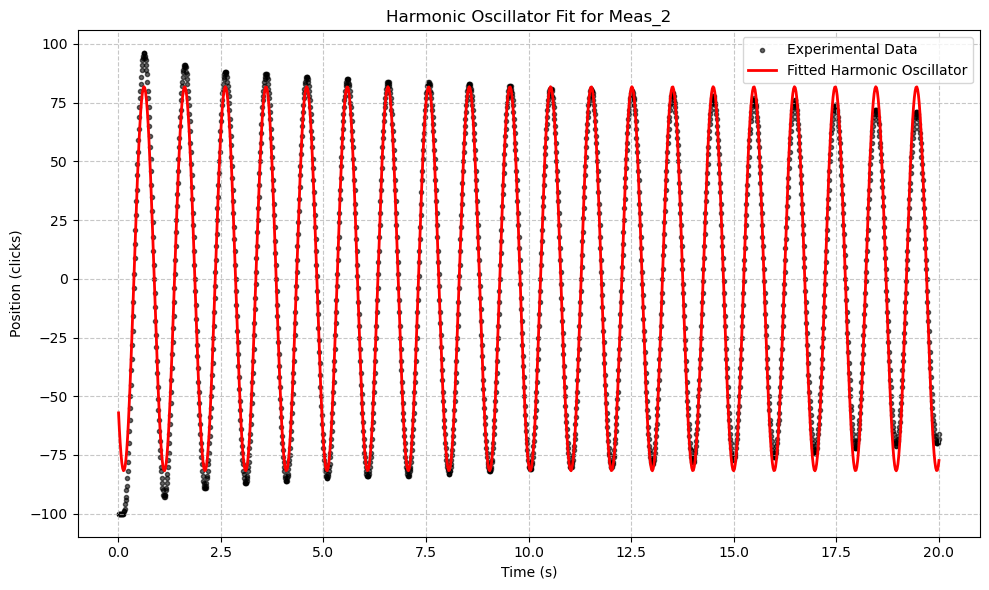


--- Fit Results for Meas_3 ---
Amplitude (A): 83.286±0.231 clicks
Angular Freq (omega): 6.34245±0.00196 rad/s
Frequency (f): 1.009433±0.000311 Hz
Phase (phi): -2.28797±0.00574 rad
Offset: -0.591±0.165 clicks


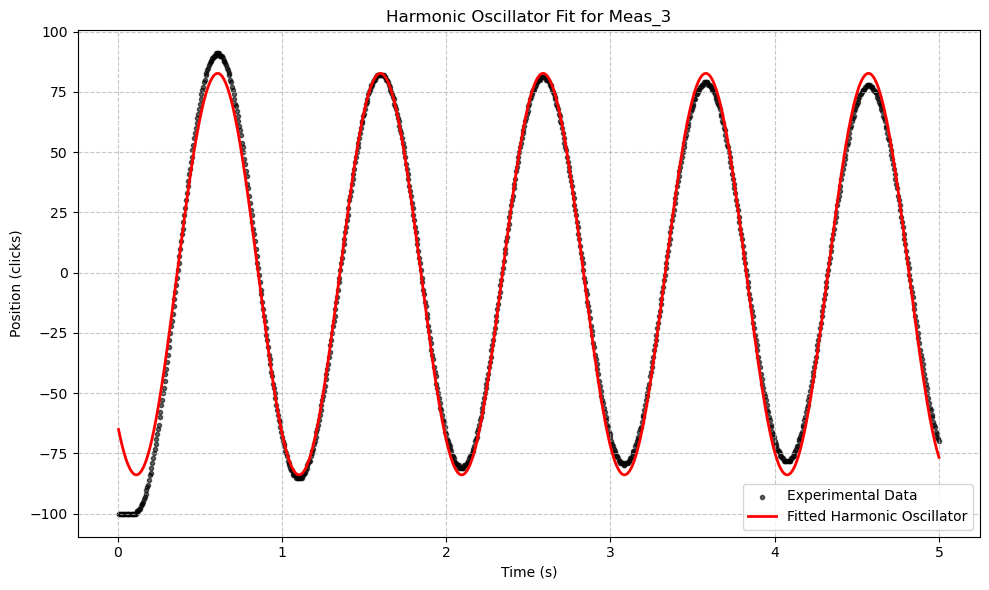

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import uncertainties as unc
import uncertainties.umath as umath

def oscillator_func(t, A, omega, phi, offset):
    """
    y(t) = A * sin(omega * t + phi) + offset
    """
    return A * np.sin(omega * t + phi) + offset

for name, path in {'Meas_1': 'simple_harmonic_1_fixed.txt',
                   'Meas_2': 'simple_harmonic_2.txt',
                   'Meas_3': 'simple_harmonic_3.txt'
    }.items():

    df = pd.read_csv(path,
                     sep='\t',
                    skiprows=1,
                    names=['index', 'time', 'count_A', 'count_B', 'count_C', 'count_D']
    )
    t = df['time'].values
    y = df['count_A'].values

    guess_offset = np.mean(y)
    guess_A = (np.max(y) - np.min(y)) / 2.0

    # Use FFT to guess the frequency (omega) accurately
    dt = t[1] - t[0]
    fft_y = np.fft.fft(y - guess_offset)
    fft_freqs = np.fft.fftfreq(len(t), d=dt)
    # Find the peak frequency in the positive half of the FFT
    idx_max = np.argmax(np.abs(fft_y[fft_freqs > 0]))
    guess_f = fft_freqs[fft_freqs > 0][idx_max]
    guess_omega = 2 * np.pi * guess_f
    guess_phi = 0.0

    # Special guess for case 2
    if '2' in name:
        guess_A = 90.0
        guess_gamma = 0.015
        guess_omega = 6.35
        guess_phi = 1.5
        guess_offset = -5.0

    p0 = [guess_A, guess_omega, guess_phi, guess_offset]

    # 4. Fit the curve to the data
    popt, pcov = curve_fit(oscillator_func, t, y, p0=p0)

    # 5. Integrate with the `uncertainties` library
    # correlated_values takes the optimal parameters and the covariance matrix
    # and creates variables that know their errors AND correlations.
    A_fit, omega_fit, phi_fit, offset_fit = unc.correlated_values(popt, pcov)

    # Calculate frequency from omega (f = omega / 2*pi)
    f_fit = omega_fit / (2 * np.pi)

    # Ensure Amplitude is positive (a negative amplitude just means a pi phase shift)
    if A_fit.nominal_value < 0:
        A_fit = -A_fit
        phi_fit = phi_fit + np.pi

    # Wrap phase to be between -pi and pi for readability
    phi_val = (phi_fit.nominal_value + np.pi) % (2 * np.pi) - np.pi
    phi_fit = unc.ufloat(phi_val, phi_fit.std_dev)

    # 6. Print the results with uncertainties
    print(f"\n--- Fit Results for {name} ---")
    print(f"Amplitude (A): {A_fit:.3uP} clicks")
    print(f"Angular Freq (omega): {omega_fit:.3uP} rad/s")
    print(f"Frequency (f): {f_fit:.3uP} Hz")
    print(f"Phase (phi): {phi_fit:.3uP} rad")
    print(f"Offset: {offset_fit:.3uP} clicks")

    table.add_row([name, A_fit, '', omega_fit, phi_fit])

    # 7. Plotting the original data and the fit
    plt.figure(figsize=(10, 6))

    # Plot raw data
    plt.scatter(t, y, label='Experimental Data', color='black', marker='.', alpha=0.6)

    # Create a smooth line for the fitted curve
    t_smooth = np.linspace(min(t), max(t), 1000)
    y_smooth = oscillator_func(t_smooth, *popt)

    # Plot fitted curve
    plt.plot(t_smooth, y_smooth, label='Fitted Harmonic Oscillator', color='red', linewidth=2)

    plt.title(f"Harmonic Oscillator Fit for {name}")
    plt.xlabel('Time (s)')
    plt.ylabel('Position (clicks)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.savefig(f"oscillator_fit_{name}.png", dpi=300)
    plt.show()


--- Fit Results for Meas_1 ---
Amplitude (A): 101.720±0.193 clicks
Angular Freq (omega): 6.245701±0.000485 rad/s
Gamma: 0.120568±0.000475 1/s
Frequency (f): 0.9940342±0.0000773 Hz
Phase (phi): -2.42063±0.00199 rad
Offset: -0.2578±0.0536 clicks


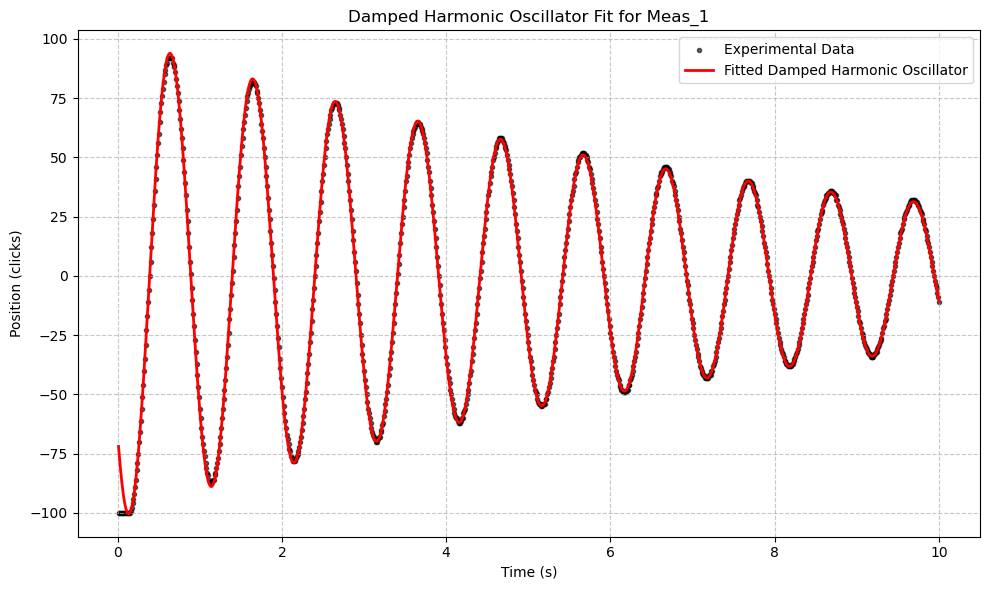


--- Fit Results for Meas_2 ---
Amplitude (A): 100.221±0.103 clicks
Angular Freq (omega): 6.247605±0.000207 rad/s
Gamma: 0.131226±0.000203 1/s
Frequency (f): 0.9943372±0.0000329 Hz
Phase (phi): -2.24861±0.00107 rad
Offset: -0.0873±0.0222 clicks


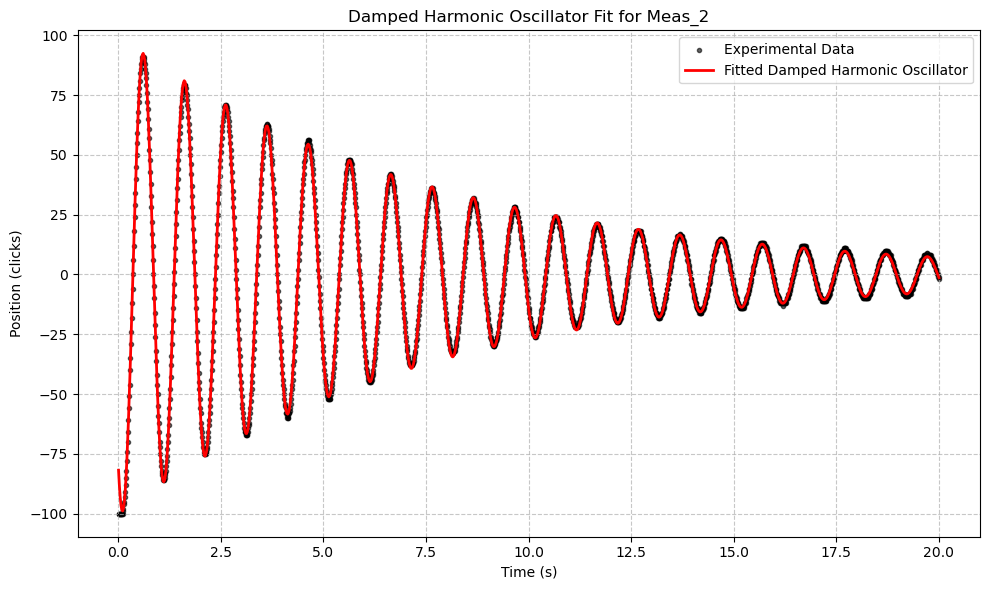


--- Fit Results for Meas_3 ---
Amplitude (A): 100.155±0.113 clicks
Angular Freq (omega): 6.246144±0.000480 rad/s
Gamma: 0.120027±0.000471 1/s
Frequency (f): 0.9941046±0.0000764 Hz
Phase (phi): -2.13595±0.00121 rad
Offset: -0.3766±0.0360 clicks


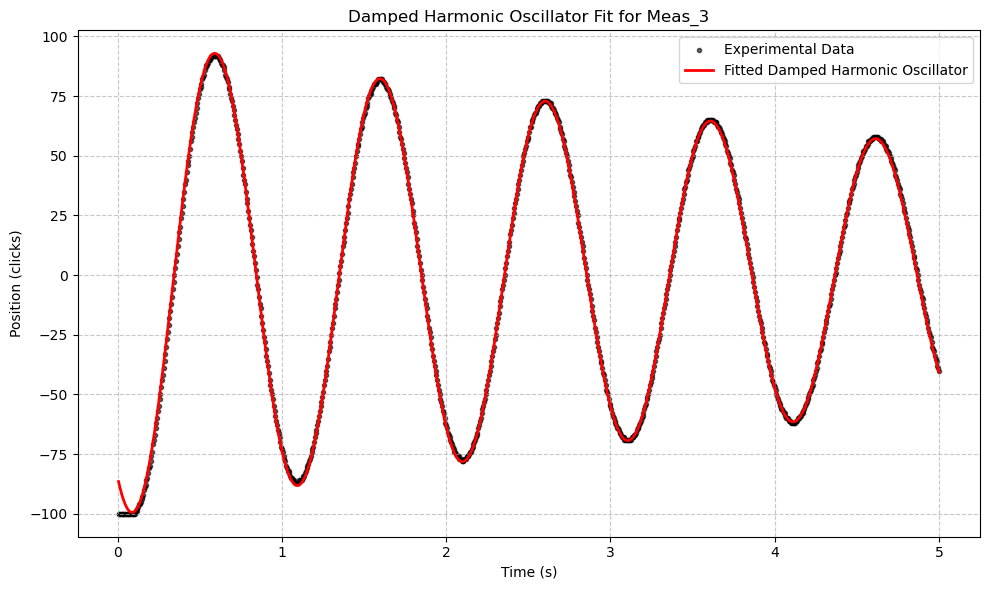


--- Fit Results for Meas_4 ---
Amplitude (A): 99.846±0.191 clicks
Angular Freq (omega): 6.247843±0.000355 rad/s
Gamma: 0.125354±0.000350 1/s
Frequency (f): 0.9943750±0.0000565 Hz
Phase (phi): -2.74842±0.00197 rad
Offset: -0.2106±0.0381 clicks


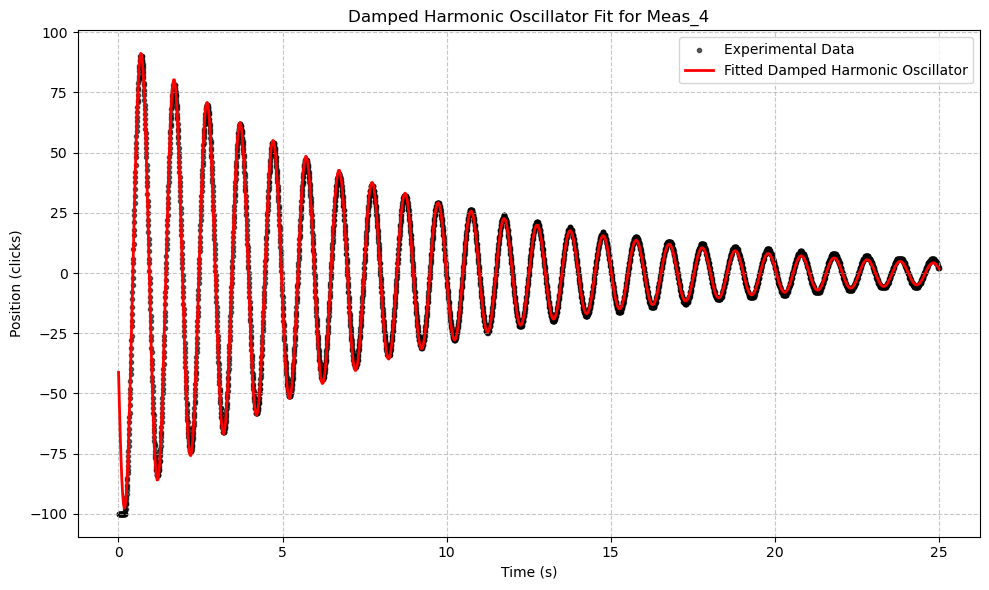


--- Fit Results for Meas_critical_damp ---
Amplitude (A): 138.61±1.17 clicks
Angular Freq (omega): 4.7327±0.0179 rad/s
Gamma: 1.2789±0.0161 1/s
Frequency (f): 0.75323±0.00285 Hz
Phase (phi): -2.5411±0.0117 rad
Offset: -2.047±0.121 clicks


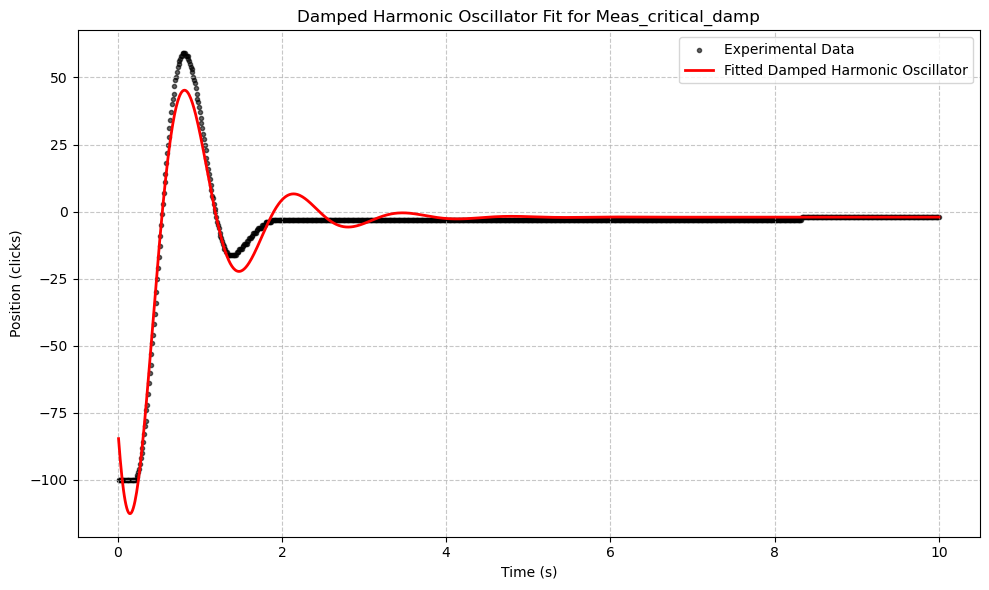

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import uncertainties as unc
import uncertainties.umath as umath

def oscillator_func(t, A, gamma, omega, phi, offset):
    """
    y(t) = A * exp(t/gamma) * sin(omega * t + phi) + offset
    """
    return A * np.exp(- t * gamma) * np.sin(omega * t + phi) + offset

for name, data in {'Meas_1': ['dump_harmonic_1_second.txt', 1],
                   'Meas_2': ['dump_harmonic_2_second.txt', 2],
                   'Meas_3': ['dump_harmonic_3_second.txt', 1.5],
                    'Meas_4': ['dump_harmonic_4_second.txt', 3],
                    'Meas_critical_damp': ["cirtical_dump.txt", 10]
    }.items():

    df = pd.read_csv(data[0],
                     sep='\t',
                    skiprows=1,
                    names=['index', 'time', 'count_A', 'count_B', 'count_C', 'count_D']
    )
    t = df['time'].values
    y = df['count_A'].values

    guess_offset = np.mean(y)
    guess_Amp = (np.max(y) - np.min(y)) / 2.0

    # Use FFT to guess the frequency (omega) accurately
    dt = t[1] - t[0]
    fft_y = np.fft.fft(y - guess_offset)
    fft_freqs = np.fft.fftfreq(len(t), d=dt)
    # Find the peak frequency in the positive half of the FFT
    idx_max = np.argmax(np.abs(fft_y[fft_freqs > 0]))
    guess_f = fft_freqs[fft_freqs > 0][idx_max]
    guess_omega = 2 * np.pi * guess_f
    guess_phi = 0.0

    guess_gamma = data[1]

    p0 = [guess_A, guess_gamma,guess_omega, guess_phi, guess_offset]

    # 4. Fit the curve to the data
    popt, pcov = curve_fit(oscillator_func, t, y, p0=p0)

    # 5. Integrate with the `uncertainties` library
    # correlated_values takes the optimal parameters and the covariance matrix
    # and creates variables that know their errors AND correlations.
    A_fit, gamma_fit, omega_fit, phi_fit, offset_fit = unc.correlated_values(popt, pcov)

    # Calculate frequency from omega (f = omega / 2*pi)
    f_fit = omega_fit / (2 * np.pi)

    # Ensure Amplitude is positive (a negative amplitude just means a pi phase shift)
    if A_fit.nominal_value < 0:
        A_fit = -A_fit
        phi_fit = phi_fit + np.pi

    # Wrap phase to be between -pi and pi for readability
    phi_val = (phi_fit.nominal_value + np.pi) % (2 * np.pi) - np.pi
    phi_fit = unc.ufloat(phi_val, phi_fit.std_dev)

    # 6. Print the results with uncertainties
    print(f"\n--- Fit Results for {name} ---")
    print(f"Amplitude (A): {A_fit:.3uP} clicks")
    print(f"Angular Freq (omega): {omega_fit:.3uP} rad/s")
    print(f"Gamma: {gamma_fit:.3uP} 1/s")
    print(f"Frequency (f): {f_fit:.3uP} Hz")
    print(f"Phase (phi): {phi_fit:.3uP} rad")
    print(f"Offset: {offset_fit:.3uP} clicks")


    table.add_row([name, A_fit, gamma_fit, omega_fit, phi_fit])


    # 7. Plotting the original data and the fit
    plt.figure(figsize=(10, 6))

    # Plot raw data
    plt.scatter(t, y, label='Experimental Data', color='black', marker='.', alpha=0.6)

    # Create a smooth line for the fitted curve
    t_smooth = np.linspace(min(t), max(t), 1000)
    y_smooth = oscillator_func(t_smooth, *popt)

    # Plot fitted curve
    plt.plot(t_smooth, y_smooth, label='Fitted Damped Harmonic Oscillator', color='red', linewidth=2)

    plt.title(f"Damped Harmonic Oscillator Fit for {name}")
    plt.xlabel('Time (s)')
    plt.ylabel('Position (clicks)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.savefig(f"damped_oscillator_fit_{name}.png", dpi=300)
    plt.show()

In [4]:
print(table)

+--------------------+--------------------+-------------------+----------------------+------------------+
|  Experiment name   | Amplitude (clicks) | Damp Factor (1/s) | Angular Freq (rad/s) |   Phase (rad)    |
+--------------------+--------------------+-------------------+----------------------+------------------+
| Theoretical Omega  |                    |                   |    6.475+/-0.006     |                  |
|       Meas_1       |    83.86+/-0.17    |                   |   6.3412+/-0.0007    |  -2.402+/-0.004  |
|       Meas_2       |    81.77+/-0.16    |                   |  6.34268+/-0.00034   |  -2.432+/-0.004  |
|       Meas_3       |    83.29+/-0.23    |                   |   6.3425+/-0.0020    |  -2.288+/-0.006  |
|       Meas_1       |   101.72+/-0.19    |  0.1206+/-0.0005  |   6.2457+/-0.0005    | -2.4206+/-0.0020 |
|       Meas_2       |   100.22+/-0.10    | 0.13123+/-0.00020 |  6.24760+/-0.00021   | -2.2486+/-0.0011 |
|       Meas_3       |   100.15+/-0.11    |  0

# Experiment OSC 2

## Calc damp factor

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import uncertainties as unc
import uncertainties.umath as umath

def oscillator_func(t, A, gamma, omega, phi, offset):
    """
    y(t) = A * exp(t/gamma) * sin(omega * t + phi) + offset
    """
    return A * np.exp(- t * gamma) * np.sin(omega * t + phi) + offset

for name, data in {'damp_factor_meas': ["", 2]}.items():

    df = pd.read_csv(data[0],
                     sep='\t',
                    skiprows=1,
                    names=['index', 'time', 'count_A', 'count_B', 'count_C', 'count_D']
    )
    t = df['time'].values
    y = df['count_A'].values

    guess_offset = np.mean(y)
    guess_Amp = (np.max(y) - np.min(y)) / 2.0

    # Use FFT to guess the frequency (omega) accurately
    dt = t[1] - t[0]
    fft_y = np.fft.fft(y - guess_offset)
    fft_freqs = np.fft.fftfreq(len(t), d=dt)
    # Find the peak frequency in the positive half of the FFT
    idx_max = np.argmax(np.abs(fft_y[fft_freqs > 0]))
    guess_f = fft_freqs[fft_freqs > 0][idx_max]
    guess_omega = 2 * np.pi * guess_f
    guess_phi = 0.0

    guess_gamma = data[1]

    p0 = [guess_A, guess_gamma,guess_omega, guess_phi, guess_offset]

    # 4. Fit the curve to the data
    popt, pcov = curve_fit(oscillator_func, t, y, p0=p0)

    # 5. Integrate with the `uncertainties` library
    # correlated_values takes the optimal parameters and the covariance matrix
    # and creates variables that know their errors AND correlations.
    A_fit, gamma_fit, omega_fit, phi_fit, offset_fit = unc.correlated_values(popt, pcov)

    # Calculate frequency from omega (f = omega / 2*pi)
    f_fit = omega_fit / (2 * np.pi)

    # Ensure Amplitude is positive (a negative amplitude just means a pi phase shift)
    if A_fit.nominal_value < 0:
        A_fit = -A_fit
        phi_fit = phi_fit + np.pi

    # Wrap phase to be between -pi and pi for readability
    phi_val = (phi_fit.nominal_value + np.pi) % (2 * np.pi) - np.pi
    phi_fit = unc.ufloat(phi_val, phi_fit.std_dev)

    # 6. Print the results with uncertainties
    print(f"\n--- Fit Results for {name} ---")
    print(f"Amplitude (A): {A_fit:.3uP} clicks")
    print(f"Angular Freq (omega): {omega_fit:.3uP} rad/s")
    print(f"Gamma: {gamma_fit:.3uP} 1/s")
    print(f"Frequency (f): {f_fit:.3uP} Hz")
    print(f"Phase (phi): {phi_fit:.3uP} rad")
    print(f"Offset: {offset_fit:.3uP} clicks")


    table.add_row([name, A_fit, gamma_fit, omega_fit, phi_fit])


    # 7. Plotting the original data and the fit
    plt.figure(figsize=(10, 6))

    # Plot raw data
    plt.scatter(t, y, label='Experimental Data', color='black', marker='.', alpha=0.6)

    # Create a smooth line for the fitted curve
    t_smooth = np.linspace(min(t), max(t), 1000)
    y_smooth = oscillator_func(t_smooth, *popt)

    # Plot fitted curve
    plt.plot(t_smooth, y_smooth, label='Fitted Damped Harmonic Oscillator', color='red', linewidth=2)

    plt.title(f"Damped Harmonic Oscillator Fit for {name}")
    plt.xlabel('Time (s)')
    plt.ylabel('Position (clicks)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.savefig(f"damped_oscillator_fit_{name}.png", dpi=300)
    plt.show()

## Calc and plot phase shift and amp ratio

In [ ]:
def theoretical_amplitude(omega, omega_0, tau, F0_m):
    """
    Calculates the amplitude of the oscillator.
    Based on the theoretical equation from the lab manual.
    """
    denominator = np.sqrt((omega_0**2 - omega**2)**2 + (omega/tau)**2)
    return F0_m / denominator

def theoretical_phase(omega, omega_0, tau):
    """
    Calculates the phase difference.
    Uses arctan2 to naturally handle the 0 to 180 degrees (0 to pi) phase shift requirement.
    """
    # The numerator is related to the damping term (omega/tau)
    # The denominator is related to the restoring force (omega_0**2 - omega**2)
    return np.arctan2((omega/tau), (omega_0**2 - omega**2))

Found 22 experiment data files to process...

     DAMPING FACTOR (τ) EXTRACTION SUMMARY
From Lorentzian (Amp) Fit : τ = 1.4494 ± 0.0008 s
From Arctan (Phase) Fit   : τ = 1.2879 ± 0.0014 s


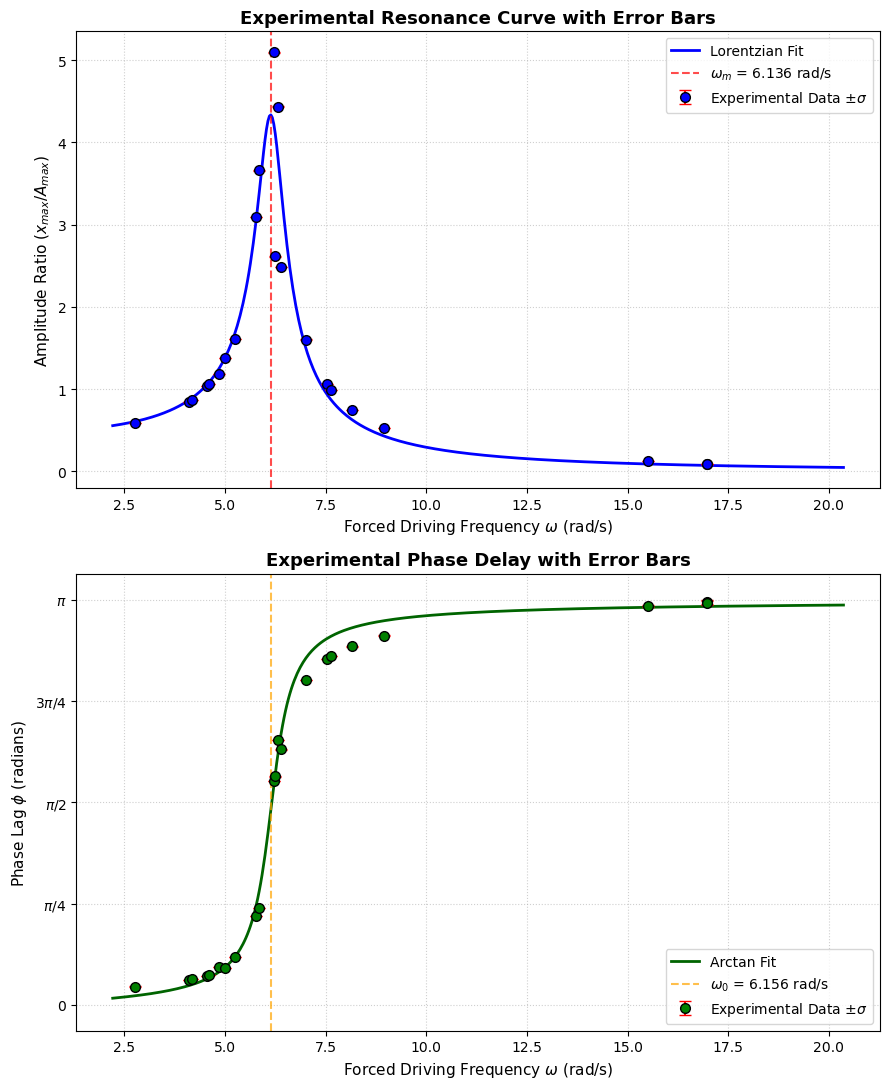


                    SUMMARY OF FORCED RESONANCE EXPERIMENTS                 
+--------------+----------------+-----------------+-----------------------+-----------------+
| File Name    | Driving Freq ω |   Amp Ratio ± σ | Phase Lag ϕ (rad) ± σ | Phase Lag ϕ (°) |
+--------------+----------------+-----------------+-----------------------+-----------------+
| nisui6.txt   |         2.7705 | 0.5903 ± 0.0010 |       0.1413 ± 0.0034 |           8.09° |
| nisui7.txt   |         4.1192 | 0.8487 ± 0.0005 |       0.1907 ± 0.0012 |          10.93° |
| nisui3.txt   |         4.1880 | 0.8738 ± 0.0005 |       0.2013 ± 0.0012 |          11.53° |
| nisui4.txt   |         4.5546 | 1.0340 ± 0.0006 |       0.2243 ± 0.0011 |          12.85° |
| nisui8.txt   |         4.6038 | 1.0659 ± 0.0006 |       0.2317 ± 0.0011 |          13.27° |
| nisui13B.txt |         4.8620 | 1.1861 ± 0.0008 |       0.2943 ± 0.0013 |          16.86° |
| nisui5.txt   |         4.9998 | 1.3838 ± 0.0007 |       0.2874 ± 0.0010 | 

In [39]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from prettytable import PrettyTable

# ==========================================
# 1. SET THE PATH TO YOUR DATA FOLDER
# ==========================================
DATA_FOLDER = 'reso_lab'

# ==========================================
# 2. SINE WAVE FUNCTION FOR FITTING
# ==========================================
def sine_model(t, amp, omega, phase, offset):
    """Standard sine wave model to extract amplitude, frequency, and phase."""
    return amp * np.sin(omega * t + phase) + offset

def analyze_single_file(file_path):
    """
    Reads a forced oscillation file, fits sine models, extracts physical parameters,
    and calculates propagated errors from the fit's covariance matrix.
    """
    try:
        raw_data = np.loadtxt(file_path, skiprows=1, usecols=(1, 2, 3))
    except Exception as e:
        print(f"Skipping file {os.path.basename(file_path)} due to loading error: {e}")
        return None

    t = raw_data[:, 0]
    pos_A = raw_data[:, 1] # Driving motor column
    pos_C = raw_data[:, 2] # Oscillator cart column

    # -------------------------------------------------------------
    # Estimate initial parameters using FFT
    # -------------------------------------------------------------
    dt = t[1] - t[0]
    fft_freqs = np.fft.fftfreq(len(t), d=dt)
    fft_values = np.abs(np.fft.fft(pos_A))
    idx = np.where(fft_freqs > 0)
    guess_freq_hz = fft_freqs[idx][np.argmax(fft_values[idx])]
    guess_omega = guess_freq_hz * 2 * np.pi

    guess_amp_A = (np.max(pos_A) - np.min(pos_A)) / 2
    guess_amp_C = (np.max(pos_C) - np.min(pos_C)) / 2

    guess_A = [guess_amp_A, guess_omega, 0.0, np.mean(pos_A)]
    guess_C = [guess_amp_C, guess_omega, 0.0, np.mean(pos_C)]

    # -------------------------------------------------------------
    # Fit the Sine Model and Extract Covariance Matrices
    # -------------------------------------------------------------
    try:
        popt_A, pcov_A = curve_fit(sine_model, t, pos_A, p0=guess_A, maxfev=20000)
        popt_C, pcov_C = curve_fit(sine_model, t, pos_C, p0=guess_C, maxfev=20000)
    except Exception as e:
        print(f"Fitting failed for {os.path.basename(file_path)}: {e}")
        return None

    # Calculate parameter uncertainties from the diagonal of the covariance matrix
    perr_A = np.sqrt(np.diag(pcov_A))
    perr_C = np.sqrt(np.diag(pcov_C))

    amp_fit_A, omega_fit_A, phase_fit_A, _ = popt_A
    amp_fit_C, omega_fit_C, phase_fit_C, _ = popt_C

    # Extract standard errors for amplitudes and phases
    amp_err_A, _, phase_err_A, _ = perr_A
    amp_err_C, _, phase_err_C, _ = perr_C

    # Handle potential sign flips from unconstrained fitting algebra
    if amp_fit_A < 0:
        amp_fit_A = np.abs(amp_fit_A)
        phase_fit_A += np.pi
    if amp_fit_C < 0:
        amp_fit_C = np.abs(amp_fit_C)
        phase_fit_C += np.pi

    driving_omega = omega_fit_A

    # Corrected Upright Ratio: Oscillator (C) / Driver (A)
    amplitude_ratio = amp_fit_C / amp_fit_A

    # 1. Propagated Error for Amplitude Ratio via standard fraction derivatives
    ratio_err = amplitude_ratio * np.sqrt((amp_err_C / amp_fit_C)**2 + (amp_err_A / amp_fit_A)**2)

    # Corrected Phase Difference order
    phase_diff = phase_fit_C - phase_fit_A
    phase_diff = np.mod(phase_diff + np.pi, 2 * np.pi) - np.pi
    phase_diff = np.abs(phase_diff)

    # 2. Propagated Error for Phase Difference (Quadrature addition)
    phase_diff_err = np.sqrt(phase_err_C**2 + phase_err_A**2)

    return driving_omega, amplitude_ratio, ratio_err, phase_diff, phase_diff_err

# ==========================================
# 3. BATCH PROCESS ALL EXPERIMENT FILES
# ==========================================
file_pattern = os.path.join(DATA_FOLDER, "*.txt")
all_files = glob.glob(file_pattern)
experiment_files = [f for f in all_files if "dump_harmonic" not in os.path.basename(f)]

file_names = []
frequencies = []
amp_ratios = []
amp_ratios_err = []
phase_diffs = []
phase_diffs_err = []

print(f"Found {len(experiment_files)} experiment data files to process...")

for file_path in experiment_files:
    results = analyze_single_file(file_path)
    if results is not None:
        omega_d, ratio, r_err, p_diff, p_err = results
        file_names.append(os.path.basename(file_path))
        frequencies.append(omega_d)
        amp_ratios.append(ratio)
        amp_ratios_err.append(r_err)
        phase_diffs.append(p_diff)
        phase_diffs_err.append(p_err)

# Convert tracking lists to sorted numpy arrays based on frequency
if len(frequencies) > 0:
    sort_indices = np.argsort(frequencies)
    file_names = [file_names[i] for i in sort_indices]
    frequencies = np.array(frequencies)[sort_indices]
    amp_ratios = np.array(amp_ratios)[sort_indices]
    amp_ratios_err = np.array(amp_ratios_err)[sort_indices]
    phase_diffs = np.array(phase_diffs)[sort_indices]
    phase_diffs_err = np.array(phase_diffs_err)[sort_indices]
else:
    raise ValueError("No valid experimental points were parsed. Check file contents or path settings.")

# ==========================================
# 4. GLOBAL THEORETICAL CURVE FITTING & EXTRACTION
# ==========================================
def theoretical_ratio(omega, omega_0, tau, k1_m):
    return k1_m / np.sqrt((omega_0**2 - omega**2)**2 + (omega/tau)**2)

def theoretical_phase(omega, omega_0, tau):
    return np.arctan2((omega/tau), (omega_0**2 - omega**2))

# Smart initial parameter generation based on raw collected vectors
guess_omega_0 = frequencies[np.argmax(amp_ratios)]  # Freq at max amplitude ratio
guess_tau = 1.0
guess_k1_m = np.max(amp_ratios) * (guess_omega_0 / guess_tau)

# Define physical boundaries to guide the solvers
lower_bounds_amp = [4.0, 0.1, 1e-5]
upper_bounds_amp = [9.0, 5.0, np.inf]

lower_bounds_phase = [4.0, 0.1]
upper_bounds_phase = [9.0, 5.0]

# --- TRACK A: Extracting tau from the Lorentzian (Amplitude) Fit ---
try:
    popt_amp, pcov_amp = curve_fit(
        theoretical_ratio,
        frequencies,
        amp_ratios,
        p0=[guess_omega_0, guess_tau, guess_k1_m],
        sigma=amp_ratios_err,
        absolute_sigma=True,
        bounds=(lower_bounds_amp, upper_bounds_amp),
        maxfev=10000
    )
    perr_amp = np.sqrt(np.diag(pcov_amp))

    omega_0_amp = popt_amp[0]
    tau_amp = popt_amp[1]          # <--- Extracted tau
    tau_amp_err = perr_amp[1]      # <--- Extracted tau error

    amp_fit_success = True
except Exception as e:
    print(f"\n[Warning] Lorentzian (Amplitude) curve fitting failed: {e}")
    amp_fit_success = False

# --- TRACK B: Extracting tau from the Arctan (Phase) Fit ---
try:
    popt_phase, pcov_phase = curve_fit(
        theoretical_phase,
        frequencies,
        phase_diffs,
        p0=[guess_omega_0, guess_tau],
        sigma=phase_diffs_err,
        absolute_sigma=True,
        bounds=(lower_bounds_phase, upper_bounds_phase),
        maxfev=10000
    )
    perr_phase = np.sqrt(np.diag(pcov_phase))

    omega_0_phase = popt_phase[0]
    tau_phase = popt_phase[1]      # <--- Extracted tau
    tau_phase_err = perr_phase[1]  # <--- Extracted tau error

    phase_fit_success = True
except Exception as e:
    print(f"\n[Warning] Arctan (Phase) curve fitting failed: {e}")
    phase_fit_success = False

# ==========================================
# PRINT RESULTS UNDER YOUR TABLES
# ==========================================
print("\n" + "="*50)
print("     DAMPING FACTOR (\u03c4) EXTRACTION SUMMARY")
print("="*50)
if amp_fit_success:
    print(f"From Lorentzian (Amp) Fit : \u03c4 = {tau_amp:.4f} \u00b1 {tau_amp_err:.4f} s")
else:
    print("From Lorentzian (Amp) Fit : Fit Failed")

if phase_fit_success:
    print(f"From Arctan (Phase) Fit   : \u03c4 = {tau_phase:.4f} \u00b1 {tau_phase_err:.4f} s")
else:
    print("From Arctan (Phase) Fit   : Fit Failed")
print("="*50)
# ==========================================
# 5. PLOT EXPERIMENTAL POINTS WITH ERROR BARS VS FIT
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 11))
freq_smooth = np.linspace(frequencies.min() * 0.8, frequencies.max() * 1.2, 500)

# --- Plot A: Amplitude Ratio Response ---
# Replaced scatter with errorbar plotting
ax1.errorbar(frequencies, amp_ratios, yerr=amp_ratios_err, fmt='bo', ecolor='red',
             elinewidth=1.5, capsize=4, ms=7, mec='black', zorder=3, label='Experimental Data $\\pm\\sigma$')
if fit_successful:
    ratio_smooth = theoretical_ratio(freq_smooth, omega_0_amp, tau_amp, k1_m_forced)
    ax1.plot(freq_smooth, ratio_smooth, color='blue', linestyle='-', linewidth=2, label='Lorentzian Fit')
    ax1.axvline(omega_m_forced, color='red', linestyle='--', alpha=0.7, label=f'$\\omega_m$ = {omega_m_forced:.3f} rad/s')
ax1.set_title("Experimental Resonance Curve with Error Bars", fontsize=13, fontweight='bold')
ax1.set_xlabel("Forced Driving Frequency $\\omega$ (rad/s)", fontsize=11)
ax1.set_ylabel("Amplitude Ratio ($x_{max} / A_{max}$)", fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# --- Plot B: Phase Difference Lag Response ---
# Replaced scatter with errorbar plotting
ax2.errorbar(frequencies, phase_diffs, yerr=phase_diffs_err, fmt='go', ecolor='red',
             elinewidth=1.5, capsize=4, ms=7, mec='black', zorder=3, label='Experimental Data $\\pm\\sigma$')
if fit_successful:
    phase_smooth = theoretical_phase(freq_smooth, omega_0_phase, tau_phase)
    ax2.plot(freq_smooth, phase_smooth, color='darkgreen', linestyle='-', linewidth=2, label='Arctan Fit')
    ax2.axvline(omega_0_forced, color='orange', linestyle='--', alpha=0.7, label=f'$\\omega_0$ = {omega_0_forced:.3f} rad/s')
ax2.set_title("Experimental Phase Delay with Error Bars", fontsize=13, fontweight='bold')
ax2.set_xlabel("Forced Driving Frequency $\\omega$ (rad/s)", fontsize=11)
ax2.set_ylabel("Phase Lag $\\phi$ (radians)", fontsize=11)
ax2.set_yticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax2.set_yticklabels(['0', '$\\pi/4$', '$\\pi/2$', '$3\\pi/4$', '$\\pi$'])
ax2.set_ylim(-0.2, np.pi + 0.2)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 6. GENERATE AND PRINT NUMERICAL PRETTYTABLE
# ==========================================
res_table = PrettyTable()
res_table.field_names = ["File Name", "Driving Freq \u03c9", "Amp Ratio \u00b1 \u03c3", "Phase Lag \u03d5 (rad) \u00b1 \u03c3", "Phase Lag \u03d5 (\u00b0)"]

for idx in range(len(frequencies)):
    w = frequencies[idx]
    ratio = amp_ratios[idx]
    r_err = amp_ratios_err[idx]
    p_rad = phase_diffs[idx]
    p_err = phase_diffs_err[idx]
    p_deg = np.degrees(p_rad)

    res_table.add_row([
        file_names[idx],
        f"{w:.4f}",
        f"{ratio:.4f} \u00b1 {r_err:.4f}",
        f"{p_rad:.4f} \u00b1 {p_err:.4f}",
        f"{p_deg:.2f}°"
    ])

res_table.align = "r"
res_table.align["File Name"] = "l"
print("\n" + "="*85)
print("                    SUMMARY OF FORCED RESONANCE EXPERIMENTS                 ")
print("="*85)
print(res_table)
print("="*85)

if fit_successful:
    print("\n" + "="*40)
    print("   EXTRACTED PHYSICS PARAMETERS (FORCED)")
    print("="*40)
    print(f"Natural Frequency (\u03c9_0) : {omega_0_forced:.4f} rad/s")
    print(f"Resonance Frequency (\u03c9_m): {omega_m_forced:.4f} rad/s")
    print(f"Damping Constant (\u03c4)    : {tau_forced:.4f} s")
    print(f"Bandwidth (\u0394\u03c9)          : {delta_omega_forced:.4f} rad/s")
    print(f"Quality Factor (Q) from lorentzian      : {omega_0_amp*tau_amp:.4f}")
    print(f"Quality Factor (Q) from phase      : {omega_0_phase*tau_phase:.4f}")
    print("="*40)

## counts plots

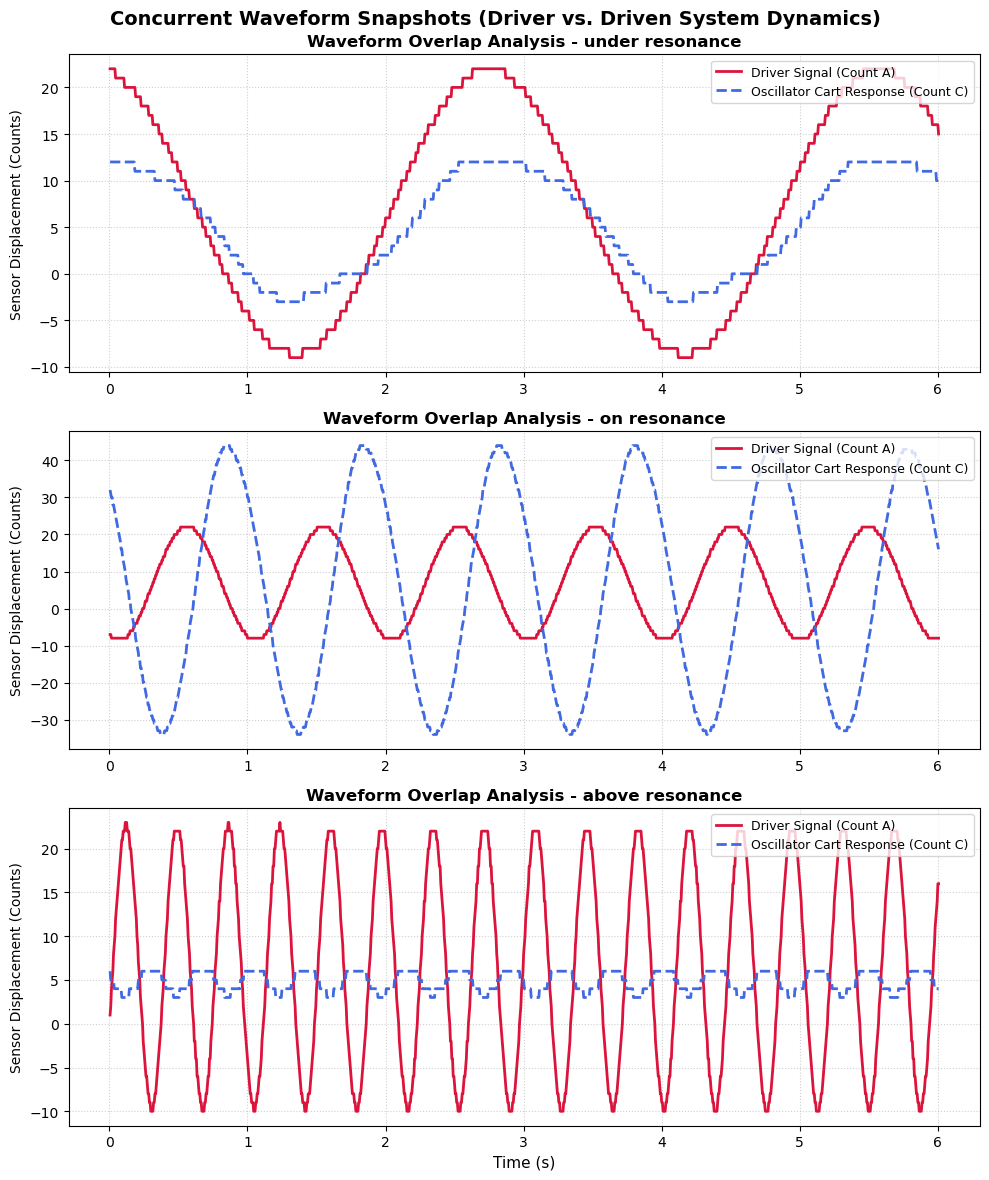

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURE YOUR DATA PATH & TARGET FILES
# ==========================================
DATA_FOLDER = '.'

# Replace these string names with the exact filenames of your three special files
SPECIAL_FILES = {
    "under": 'nisuiC-under.txt',
    "on" : 'nisuiC-reso.txt',
    "above": 'nisuiC_above.txt'
}

# ==========================================
# 2. GENERATE TRIPLE COMPARISON CHART
# ==========================================
# Create a layout with 3 vertical subplots sharing a clean structure
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=False)

files_plotted = 0

for idx, (title, file_name) in enumerate(SPECIAL_FILES.items()):
    file_path = os.path.join(DATA_FOLDER, file_name)
    ax = axes[idx]

    if not os.path.exists(file_path):
        ax.text(0.5, 0.5, f"File Not Found:\n{file_name}",
                ha='center', va='center', color='darkred', fontsize=12)
        ax.set_title(f"Slot {idx+1}: Missing Data Artifact")
        continue

    try:
        # Loading data columns: Index 1 = Time, Index 2 = Count A, Index 3 = Count C
        raw_data = np.loadtxt(file_path, skiprows=1, usecols=(1, 2, 3))
        time = raw_data[:, 0]
        count_A = raw_data[:, 1]
        count_C = raw_data[:, 2]

        # --- Slicing to view a clean snapshot window ---
        # If your data runs for a long time, plotting everything makes it look solid colored.
        # Here we isolate just the first 3 seconds to clearly display individual wave shapes.
        mask = (time >= time[0]) & (time <= time[0] + 6.0)

        # Plot Driver Waveform (Count A)
        ax.plot(time[mask], count_A[mask], color='crimson', linewidth=2,
                label='Driver Signal (Count A)')

        # Plot Oscillator Waveform (Count C)
        ax.plot(time[mask], count_C[mask], color='royalblue', linewidth=2,
                linestyle='--', label='Oscillator Cart Response (Count C)')

        # Graphical labels and clean formatting styles
        ax.set_title(f"Waveform Overlap Analysis - {title} resonance", fontsize=12, fontweight='bold')
        ax.set_ylabel("Sensor Displacement (Counts)", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=9)

        # Only add the time label to the bottom-most plot to maintain layout clean lines
        if idx == 2:
            ax.set_xlabel("Time (s)", fontsize=11)

        files_plotted += 1

    except Exception as e:
        ax.text(0.5, 0.5, f"Parsing Error in {file_name}:\n{str(e)}",
                ha='center', va='center', color='darkred', fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.3)

if files_plotted > 0:
    plt.suptitle("Concurrent Waveform Snapshots (Driver vs. Driven System Dynamics)",
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print("[Error] None of the specified target text files could be read from the folder location.")